## Setup

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skmiscpy import here

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
import re
import unicodedata

def clean_names(
    df: pd.DataFrame,
    case: str = "snake",
    remove_special: bool = True,
    strip_accents: bool = True,
    strip_underscores: str | bool = "both",
    truncate: int | None = None,
) -> pd.DataFrame:
    """
    Clean column names in a pandas DataFrame (janitor-style).

    Parameters
    ----------
    case : {"snake", "lower", "upper", "preserve"}
    remove_special : remove non-alphanumeric characters
    strip_accents : remove unicode accents
    strip_underscores : {"left", "right", "both", True, None}
    truncate : int, optional max length

    Returns
    -------
    pd.DataFrame
    """

    def _clean(col: str) -> str:
        col = str(col)

        if strip_accents:
            col = "".join(
                c for c in unicodedata.normalize("NFD", col)
                if not unicodedata.combining(c)
            )

        col = re.sub(r"[ /:,?()\.\-]+", "_", col)
        col = re.sub(r"['’]", "", col)
        col = re.sub(r"\xa0", "_", col)
        col = re.sub(r"(\w)@(\w)", r"\1_\2", col)

        # --- case handling ---
        if case == "snake":
            col = re.sub(r"(.)([A-Z][a-z]+)", r"\1_\2", col)
            col = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", col)
            col = col.lower()
        elif case == "lower":
            col = col.lower()
        elif case == "upper":
            col = col.upper()
        elif case == "preserve":
            pass
        else:
            raise ValueError("case must be one of: snake, lower, upper, preserve")

        if remove_special:
            col = re.sub(r"[^a-zA-Z0-9_]", "", col)

        col = re.sub(r"_+", "_", col)

        if strip_underscores in {"left", "l"}:
            col = col.lstrip("_")
        elif strip_underscores in {"right", "r"}:
            col = col.rstrip("_")
        elif strip_underscores in {"both", True}:
            col = col.strip("_")

        if truncate:
            col = col[:truncate]

        return col

    return df.rename(columns=_clean)

In [5]:
def compute_vif(df):

    X = df.select_dtypes(include='number').dropna()

    return pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False)

In [35]:
def get_tpr_fpr(probs, y_truth, threshold=0.5):
    preds = (probs >= threshold)

    tp = (preds == 1) & (y_truth == 1)
    tn = (preds == 0) & (y_truth == 0)
    fp = (preds == 1) & (y_truth == 0)
    fn = (preds == 0) & (y_truth == 1)

    tpr = tp.sum() / (tp.sum() + fn.sum())
    fpr = fp.sum() / (fp.sum() + tn.sum())

    return tpr, fpr

In [62]:
from typing import Iterable, Optional, Union
from sklearn.base import ClassifierMixin
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.utils.validation import check_is_fitted


def evaluate_thresholds(
    model: ClassifierMixin,
    X: Union[np.ndarray, pd.DataFrame],
    y: Union[np.ndarray, pd.Series],
    thresholds: Optional[Iterable[float]] = None,
    pos_label: Union[int, str] = 1,
    use_proba: bool = True,
    zero_division: int = 0
) -> pd.DataFrame:
    """
    Evaluate classification metrics across thresholds.
    """

    try:
        check_is_fitted(model)
    except Exception as e:
        raise ValueError(
            "The model appears to be unfitted. Call `fit()` before using this function."
        ) from e

    if use_proba:
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X)[:, 1]
        else:
            raise ValueError("Model does not support predict_proba")
    else:
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X)

            denom = scores.max() - scores.min()
            scores = (scores - scores.min()) / denom if denom > 0 else np.zeros_like(scores)
        else:
            raise ValueError("Model does not support decision_function")

    if thresholds is None:
        thresholds = np.linspace(0, 1, 101)

    results = []
    
    for t in thresholds:
        y_pred = (scores >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        results.append({
            "threshold": float(t),
            "precision": precision_score(y, y_pred, pos_label=pos_label, zero_division=zero_division),
            "recall": recall_score(y, y_pred, pos_label=pos_label, zero_division=zero_division),
            "f1": f1_score(y, y_pred, pos_label=pos_label, zero_division=zero_division),
            "tpr": tpr,
            "fpr": fpr,
            "accuracy": accuracy_score(y, y_pred),
        })

    return pd.DataFrame(results)

In [ ]:
pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv(here("data/raw/telco-customer-churn.csv"))

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## EDA & Data Cleanup

In [9]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [10]:
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'
]

multi_cat_cols = ['Contract', 'PaymentMethod']

internet_service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
    'StreamingTV', 'StreamingMovies'
]

df.filter(items=internet_service_cols).sample(5)

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
3818,Yes,Yes,No,Yes,Yes,Yes
4011,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
1683,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
6126,No,No,Yes,No,Yes,Yes
2990,No,No,No,No,No,Yes


In [11]:
processed_df = (
    df
    .pipe(lambda df_: df_.assign(**{
            c: df_[c].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}).astype('int8')
            for c in binary_cols
        })
    )
    .assign(
        multiple_lines=lambda df_: (
            df_['MultipleLines']
            .replace({'No phone service': 'No'})
            .map({'Yes': 1, 'No': 0})
            .astype('int8')
        ),
        no_internet_service=lambda df_: (df_['InternetService'] == 'No').astype('int8'),
        dsl_internet_service=lambda df_: (df_['InternetService'] == 'DSL').astype('int8')
    )
    .pipe(lambda df_: df_.assign(**{
            c: df_[c].replace({'No internet service': 'No'}).map({'Yes': 1, 'No': 0})
            for c in internet_service_cols
        })
    )
    .assign(
        total_charges = lambda df_: pd.to_numeric(df_['TotalCharges'], errors='coerce')
    )
    .drop(columns=['customerID', 'MultipleLines', 'InternetService', 'TotalCharges'])
    .pipe(lambda df_: df_.assign(**{
            c: df_[c].astype('int8') for c in df_.select_dtypes('bool').columns
        })
    )
    .pipe(lambda df_: pd.get_dummies(df_, columns=multi_cat_cols, drop_first=True, dtype='int8'))
    .pipe(clean_names)
)

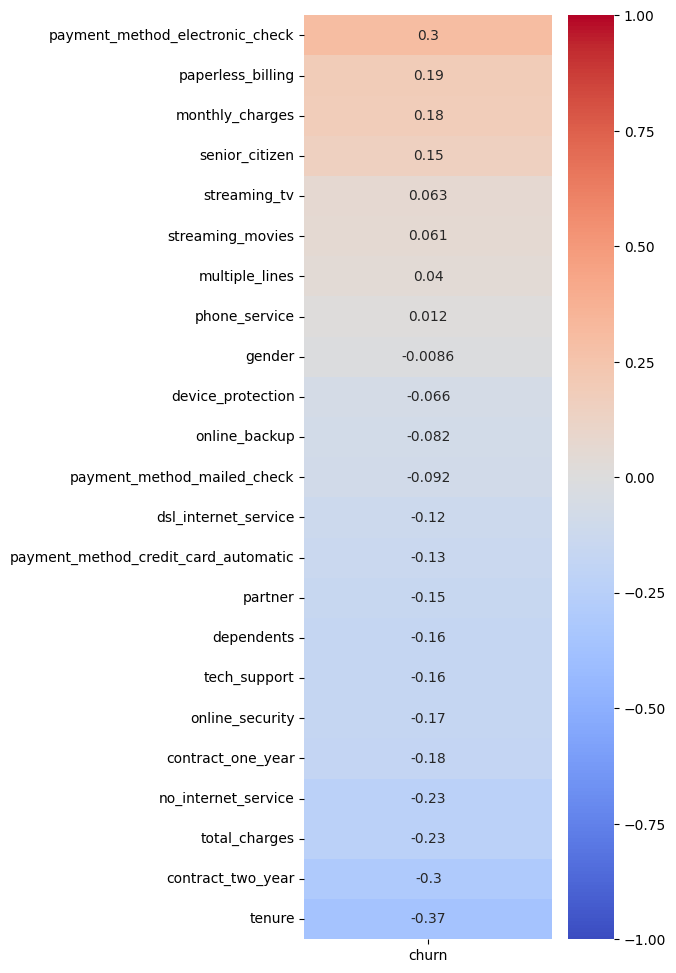

In [12]:
corr_mat = (
    processed_df
    .corr(method='spearman')[['churn']]
    .sort_values(by='churn', ascending=False)
    .iloc[1:]
)

plt.figure(figsize=(4, 12))
sns.heatmap(corr_mat, vmax=1, vmin=-1, annot=True, cmap='coolwarm')
plt.show()

In [15]:
processed_df.pipe(compute_vif)

,feature,VIF
13,monthly_charges,69.247422
5,phone_service,30.927827
18,total_charges,21.830203
4,tenure,20.767704
16,no_internet_service,8.484810
11,streaming_movies,3.659230
17,dsl_internet_service,3.611521
10,streaming_tv,3.571808
20,contract_two_year,3.496308
22,payment_method_electronic_check,2.981233


In [16]:
processed_df.churn.value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [17]:
processed_df.churn.value_counts(normalize=True)

churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

## ML

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb

import time

In [21]:
X = processed_df.drop(columns=['churn'])
y = processed_df['churn']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
X_train.shape, X_test.shape

((5634, 23), (1409, 23))

In [24]:
THRESHOLD = 0.3 # Lower than 0.5 to boost recall

### Random Forest

In [30]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

In [33]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.892     0.767     0.825      1035
           1      0.536     0.743     0.623       374

    accuracy                          0.761      1409
   macro avg      0.714     0.755     0.724      1409
weighted avg      0.798     0.761     0.771      1409



### Threshold Tuning for RF model

In [43]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

In [47]:
eval_metrics = []

rf_probs = rf.predict_proba(X_test)[:, 1]

for thresh in np.arange(0, 1, 0.05):
    y_pred = (rf_probs >= thresh).astype(int)
    tpr, fpr = get_tpr_fpr(rf_probs, y_test, threshold=thresh)

    eval_metrics.append({
        "threshold": thresh,
        "fpr": fpr,
        "tpr": tpr,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1-score": f1_score(y_test, y_pred),
        "roc": roc_auc_score(y_test, y_pred)
    })


<Axes: xlabel='threshold'>

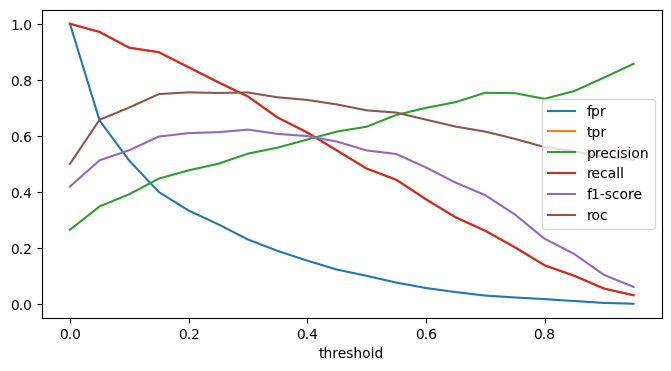

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))

(
    pd.DataFrame(eval_metrics)
    .set_index('threshold')
    .plot(ax=ax)
)

In [53]:
pd.DataFrame(eval_metrics)

,threshold,fpr,tpr,precision,recall,f1-score,roc
0,0.00,1.000000,1.000000,0.265436,1.000000,0.419518,0.500000
1,0.05,0.655072,0.970588,0.348703,0.970588,0.513074,0.657758
2,0.10,0.512077,0.914439,0.392202,0.914439,0.548957,0.701181
3,0.15,0.400000,0.898396,0.448000,0.898396,0.597865,0.749198
4,0.20,0.334300,0.844920,0.477341,0.844920,0.610039,0.755310
5,0.25,0.285024,0.791444,0.500846,0.791444,0.613472,0.753210
6,0.30,0.230918,0.740642,0.536822,0.740642,0.622472,0.754862
7,0.35,0.190338,0.665775,0.558296,0.665775,0.607317,0.737719
8,0.40,0.155556,0.612299,0.587179,0.612299,0.599476,0.728372
9,0.45,0.123671,0.548128,0.615616,0.548128,0.579915,0.712228


<Axes: xlabel='threshold'>

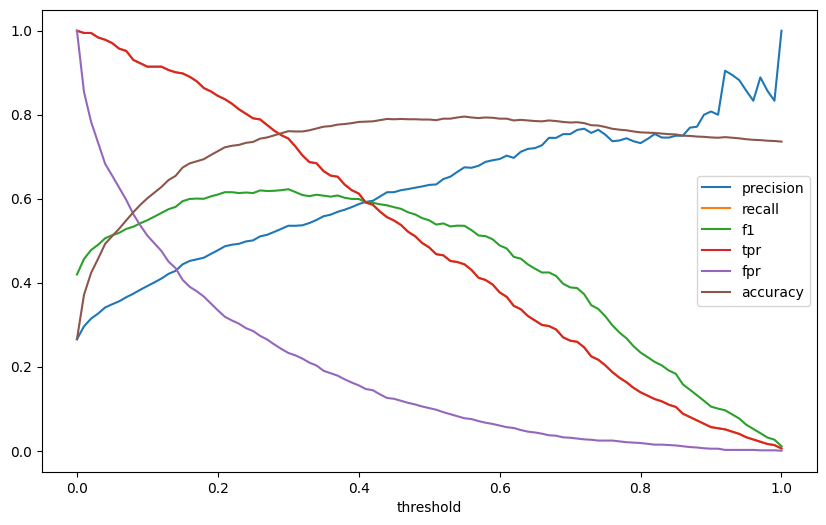

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

(
    evaluate_thresholds(
        model=rf, 
        X=X_test, 
        y=y_test
    )
    .set_index('threshold')
    .plot(ax = ax)
)

In [70]:
(
    evaluate_thresholds(
        model=rf, 
        X=X_test, 
        y=y_test
    )
    .query('recall >= 0.80 & recall <= 0.90')
    .sort_values(by='recall', ascending=False)
)


,threshold,precision,recall,f1,tpr,fpr,accuracy
15,0.15,0.443857,0.898396,0.594164,0.898396,0.406763,0.674237
16,0.16,0.451832,0.890374,0.599460,0.890374,0.390338,0.684173
17,0.17,0.455679,0.879679,0.600365,0.879679,0.379710,0.689141
18,0.18,0.459459,0.863636,0.599814,0.863636,0.367150,0.694109
19,0.19,0.468521,0.855615,0.605487,0.855615,0.350725,0.704045
20,0.20,0.477341,0.844920,0.610039,0.844920,0.334300,0.713272
21,0.21,0.486781,0.836898,0.615536,0.836898,0.318841,0.722498
22,0.22,0.490476,0.826203,0.615538,0.826203,0.310145,0.726047
23,0.23,0.492707,0.812834,0.613522,0.812834,0.302415,0.728176
24,0.24,0.498339,0.802139,0.614754,0.802139,0.291787,0.733144


So at threshold 0.24/0.25, we are getting 80% recall (TPR), 50% precision and 73% accuracy

### LightGBM

In [71]:
from lightgbm import LGBMClassifier
import time

In [74]:
lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [75]:
lgb_proba = lgb.predict_proba(X_test)[:, 1]
y_pred_lgb = (lgb_proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred_lgb, digits=3))

              precision    recall  f1-score   support

           0      0.919     0.701     0.796      1035
           1      0.501     0.829     0.624       374

    accuracy                          0.735      1409
   macro avg      0.710     0.765     0.710      1409
weighted avg      0.808     0.735     0.750      1409



<Axes: xlabel='threshold'>

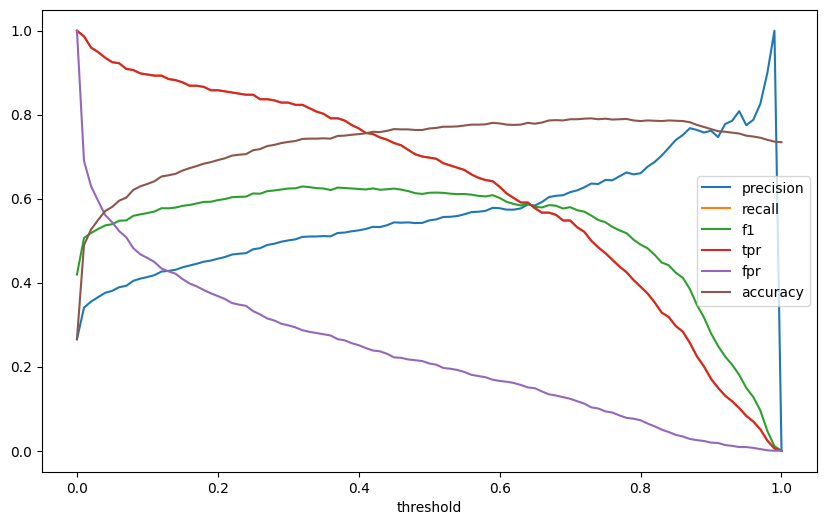

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))

(
    evaluate_thresholds(
        lgb, X_test, y_test,
        # thresholds=np.arange(0.15, 0.50, 0.01)
    )
    .set_index('threshold')
    .plot(ax = ax)
)

In [78]:
(
    evaluate_thresholds(
        lgb, X_test, y_test,
        thresholds=np.arange(0.15, 0.50, 0.01)
    )
    .query('recall >= 0.80 & recall <= 0.90')
    .sort_values(by='recall', ascending=False)
)

,threshold,precision,recall,f1,tpr,fpr,accuracy
0,0.15,0.436751,0.877005,0.583111,0.877005,0.408696,0.667140
1,0.16,0.440977,0.868984,0.585059,0.868984,0.398068,0.672818
2,0.17,0.445205,0.868984,0.588768,0.868984,0.391304,0.677786
3,0.18,0.450000,0.866310,0.592322,0.866310,0.382609,0.683463
4,0.19,0.452750,0.858289,0.592798,0.858289,0.374879,0.687012
5,0.20,0.457265,0.858289,0.596654,0.858289,0.368116,0.691980
6,0.21,0.461095,0.855615,0.599251,0.855615,0.361353,0.696238
7,0.22,0.467057,0.852941,0.603595,0.852941,0.351691,0.702626
8,0.23,0.469027,0.850267,0.604563,0.850267,0.347826,0.704755
10,0.25,0.479576,0.847594,0.612560,0.847594,0.332367,0.715401


So, at threshold 0.35, we are getting 80% recall, with 51% precision and 74% accuracy

### XGBoost

In [79]:
from xgboost import XGBClassifier

In [80]:
scale_pos_weight = (y_train == 0).sum() / (y_test == 0).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

<Axes: xlabel='threshold'>

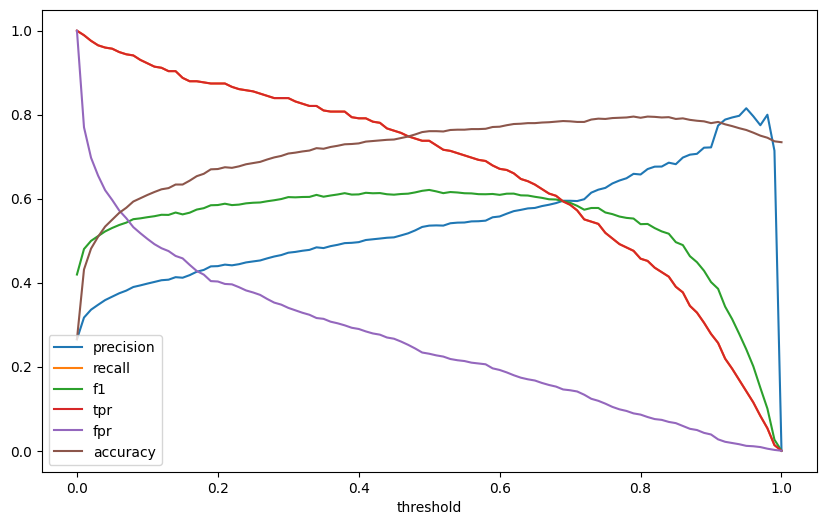

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

(
    evaluate_thresholds(
        xgb, X_test, y_test
    )
    .set_index('threshold')
    .plot(ax = ax)
)

In [82]:
(
    evaluate_thresholds(
        xgb, X_test, y_test
    )
    .query('recall >= 0.80 & recall <= 0.90')
    .sort_values(by='recall', ascending=False)
)

,threshold,precision,recall,f1,tpr,fpr,accuracy
15,0.15,0.411911,0.887701,0.562712,0.887701,0.457971,0.633783
16,0.16,0.418043,0.879679,0.566753,0.879679,0.442512,0.643009
17,0.17,0.426166,0.879679,0.574171,0.879679,0.428019,0.653655
18,0.18,0.430446,0.877005,0.577465,0.877005,0.419324,0.659333
19,0.19,0.438926,0.874332,0.584450,0.874332,0.403865,0.669979
20,0.20,0.439516,0.874332,0.584973,0.874332,0.402899,0.670688
21,0.21,0.443089,0.874332,0.588129,0.874332,0.397101,0.674947
22,0.22,0.441417,0.866310,0.584838,0.866310,0.396135,0.673527
23,0.23,0.444138,0.860963,0.585987,0.860963,0.389372,0.677076
24,0.24,0.448324,0.858289,0.588991,0.858289,0.381643,0.682044


In [85]:
XGB_THRESHOLD = 0.38

## Hyperparameter Optimization

In [84]:
import optuna

/Users/pathaoltd/Projects/telco-customer-churn/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [86]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= XGB_THRESHOLD).astype(int)
    return recall_score(y_test, y_pred, pos_label=1)

In [87]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-04-02 18:05:27,507] A new study created in memory with name: no-name-9bc0ca75-0e98-4696-851e-cf2177995a97
[I 2026-04-02 18:05:28,313] Trial 0 finished with value: 0.8449197860962567 and parameters: {'n_estimators': 651, 'learning_rate': 0.06612644234115604, 'max_depth': 9, 'subsample': 0.5690708872871204, 'colsample_bytree': 0.6012218693421657, 'min_child_weight': 7, 'gamma': 2.430110821918068, 'reg_alpha': 2.260024266589191, 'reg_lambda': 3.926957965551647}. Best is trial 0 with value: 0.8449197860962567.
[I 2026-04-02 18:05:28,654] Trial 1 finished with value: 0.8636363636363636 and parameters: {'n_estimators': 647, 'learning_rate': 0.03099910109424472, 'max_depth': 3, 'subsample': 0.8012782381892153, 'colsample_bytree': 0.6845438962426618, 'min_child_weight': 8, 'gamma': 4.475638840172815, 'reg_alpha': 3.802371897665135, 'reg_lambda': 0.7742914935888889}. Best is trial 1 with value: 0.8636363636363636.
[I 2026-04-02 18:05:28,907] Trial 2 finished with value: 0.85828877005347

In [88]:
study.best_params

{'n_estimators': 330,
 'learning_rate': 0.15942106510431633,
 'max_depth': 5,
 'subsample': 0.6995351198139865,
 'colsample_bytree': 0.8900907586691144,
 'min_child_weight': 2,
 'gamma': 4.944470930581089,
 'reg_alpha': 2.2741130099291733,
 'reg_lambda': 1.7682231076436365}

In [89]:
study.best_value

0.8796791443850267

In [91]:
scale_pos_weight = (y_train == 0).sum() / (y_test == 1).sum()
best_params = study.best_params

best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

In [92]:
xgb = XGBClassifier(**best_params)

In [93]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8900907586691144
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [94]:
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_y_pred = (xgb_proba >= XGB_THRESHOLD).astype(int)

In [95]:
print(classification_report(y_test, xgb_y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.947     0.533     0.682      1035
           1      0.415     0.917     0.572       374

    accuracy                          0.635      1409
   macro avg      0.681     0.725     0.627      1409
weighted avg      0.806     0.635     0.653      1409



In [96]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   gender                                7043 non-null   int8   
 1   senior_citizen                        7043 non-null   int64  
 2   partner                               7043 non-null   int8   
 3   dependents                            7043 non-null   int8   
 4   tenure                                7043 non-null   int64  
 5   phone_service                         7043 non-null   int8   
 6   online_security                       7043 non-null   int64  
 7   online_backup                         7043 non-null   int64  
 8   device_protection                     7043 non-null   int64  
 9   tech_support                          7043 non-null   int64  
 10  streaming_tv                          7043 non-null   int64  
 11  streaming_movies 